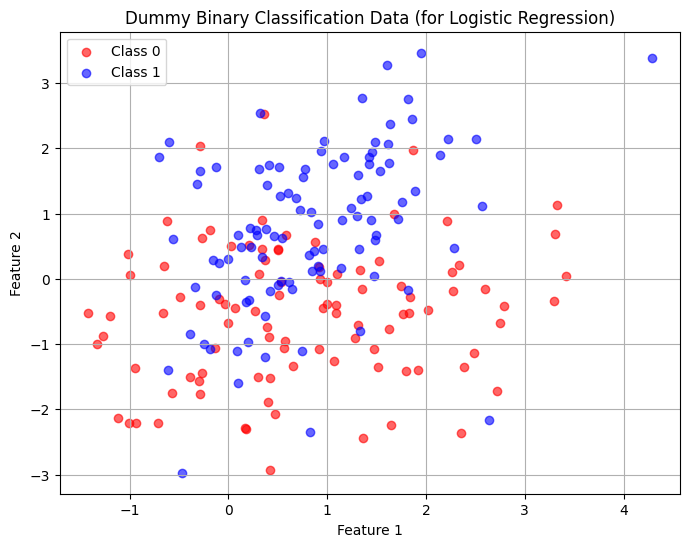

Features shape: (200, 2)
Target shape: (200,)


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Set seed
np.random.seed(42)

# Generate a classification dataset
x, y = make_classification(
    n_samples=200,
    n_features=2,          # Only 2 useful features for visualization
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,         # Low separation makes it harder
    flip_y=0.1,            # Add noise (10% label flipping)
    random_state=42
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape:", x.shape)
print("Target shape:", y.shape)

In [32]:
#initialize the values of centroids
import random

m = x.shape[0]  # Replace with your value of m
k=2
random_sequence = random.sample(range(m + 1), k)

centroid=x[random_sequence]
c=centroid
c

array([[ 0.99667242, -0.38161457],
       [ 1.14527769,  0.9080822 ]])

In [33]:
for epoch in range(100):
    k_history=[]
    average_history=[]
    for j in range(k):
        d_history=[]
        for i in range(len(x)):
            d=np.sqrt(((x[i,0]-c[j,0])**2) +((x[i,1]-c[j,1])**2))
            d_history.append(d)
        k_history.append(d_history)
    data_belongs_to = {}
    for i in range(k):
        data_belongs_to[i] = []
    for i in range(x.shape[0]):
        distance = np.inf
        for j in range(k):
            if k_history[j][i] < distance:
                indx_centroid = j
                distance = k_history[j][i]
        data_belongs_to[indx_centroid].append(i)
        
    for a in range(len(data_belongs_to)):
        c[a] = np.mean(x[data_belongs_to[a]], axis=0)

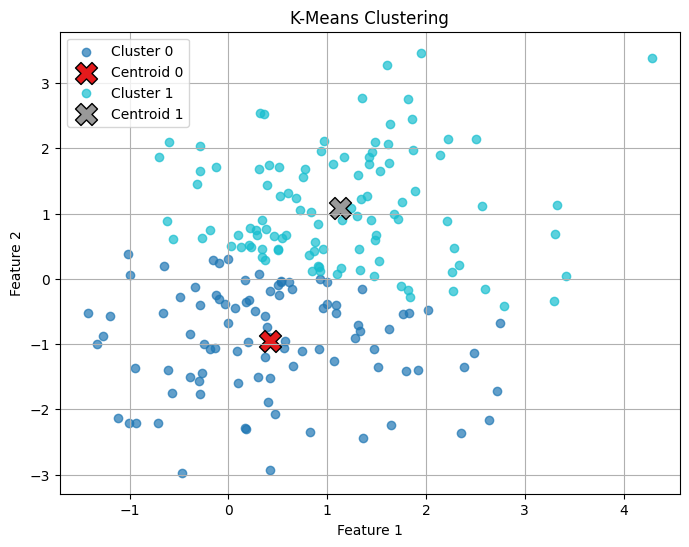

In [34]:
plt.figure(figsize=(8,6))

# Colors for clusters
cluster_colors = plt.cm.tab10(np.linspace(0, 1, k))

# Colors for centroids (different colormap)
centroid_colors = plt.cm.Set1(np.linspace(0, 1, k))

for i in range(k):
    # Plot cluster points
    plt.scatter(
        x[data_belongs_to[i], 0],
        x[data_belongs_to[i], 1],
        color=cluster_colors[i],
        label=f"Cluster {i}",
        alpha=0.7
    )

    # Plot centroid
    plt.scatter(
       c[i, 0],
        c[i, 1],
        color=centroid_colors[i],
        marker='X',
        s=250,
        edgecolors='black',
        label=f"Centroid {i}"
    )

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()